## Kelley hu4d5-5 VL-T31A error analysis

In this notebook we will use a random forest model to find the most energetically influential degrees of freedom for the VL-T31A TI production run. Next, we will compare the sampling of these DOF during TI production to a free energy profile derived from end state GaMD sampling. We will attempt to  correct any inaccurate sampling in the TI data and find the estimated ddG before and after the correction. 

In [1]:
import os
os.chdir("..")
from common_functions import *

### Ingesting initial TI data

In [2]:
os.chdir("./TI_data/VL-T31A")
geom_dvdls = pd.read_csv("T31A_bound.csv")
geom_dvdls_ub = pd.read_csv("T31A_unbound.csv")

### Computing original TI estimate and error

In [3]:
orig_dGs = np.array(bootstrap_df(geom_dvdls, 1000, 200))
orig_ub_dGs = np.array(bootstrap_df(geom_dvdls_ub, 1000, 200))

In [4]:
print("Original estimates: ")
orig_ddGs = print_summary(orig_dGs, orig_ub_dGs)

print()
empirical_value = 0.80
orig_error = abs(np.mean(orig_ddGs) - empirical_value)
print(f"Original ddG error: {round(orig_error, 4)} kcal/mol")

Original estimates: 
Total ddG: -0.1523 +/- 0.4467
Lower CI: -0.5678
Upper CI: 0.2943

Original ddG error: 0.9523 kcal/mol


### Removing correlated variables among candidate degrees of freedom

This is important because we want to limit the noise in our model training. See our methods/supplemental methods section for our process to choose the input features.

In [5]:
X = geom_dvdls.drop([
    "#Frame", "weight_dvdl", "dvdl", "Run", "Lambda", "N385_T386"
], axis=1)

Y = geom_dvdls["weight_dvdl"]

X_scl = pd.DataFrame(StandardScaler().fit_transform(X))
X_scl.columns = X.columns


### Checking to see if there is any cross-correlations within the independent variables

In [6]:
absCorr = abs(X_scl.corr())
for i in absCorr.columns:
    for j in absCorr.index:
        cor = absCorr.loc[i, j]
        if abs(cor) > 0.5 and i != j:
            print(i, j)
            print(cor)
            

### Using random forest model to identify the most energetically influential degrees of freedom

We run our model 25 times, then sort the results by the mean of feature importance across the 25 iterations. For this particular perturbation, the model $R^2$ between the geometric DOF (nearby side chain rotamers or interatomic distances) and the energetic DV/DL is relatively weak but we shall still compare the TI sampling to the GaMD free energy profile of the most energetically relevant feature which is the distance between VL-T31 and VL-R66.

In [10]:
rfeDefault = RFE(estimator=DecisionTreeRegressor(max_depth=5, random_state=42), n_features_to_select=0.75, step=0.05)
rfDefault = RandomForestRegressor(
    max_depth=10, n_estimators=200, oob_score=True, max_features=0.6, min_samples_leaf = 7, min_samples_split=14, random_state=42,
    n_jobs=-1
)

pipelineDefault_rf = Pipeline([
    ('feature_scaling', StandardScaler()),
    ('feature_selection', rfeDefault),
    ('regression_model', rfDefault)
])


imps = benchmark_model(pipelineDefault_rf, X_scl, Y, geom_dvdls["Lambda"])
imps[["Mean", "Median"]].sort_values(by="Mean", ascending=False)[:15]

Avg. training r2: 
0.5953
Training r2 std dev: 
0.0006
Avg. test r2: 
0.4283
Testing r2 std dev: 
0.0039


,Mean,Median
R421_T386,0.185431,0.185108
R421_chi3,0.083613,0.097328
T386_chi1,0.061870,0.079574
N385_chi2,0.061091,0.052598
R421_chi1,0.060598,0.069043
R421_chi2,0.059906,0.047236
Q115_T386,0.052733,0.052478
F408_chi2,0.042546,0.034958
H446_chi1,0.039118,0.042480
F408_chi1,0.036425,0.034384


### Comparing TI sampling of VL-T31...VL-R66 distance with GaMD free energy profile

When we do this comparison, we see that there is a bimodal free energy profile and it seems that certain regions (such as the most favorable region where the distance is between 7.1 and 9 Angstroms) are not quite sampled in line with the pmf distribution. 

We shall do a proportion-based correction on the microstates, although it is clear that there is some element of this mutation we are currently not capturing with our TI simulations. We can use this R66 distance as a proxy to try to delve deeper into what is introducing the ~1 kcal/mol error in this ddG estimation.

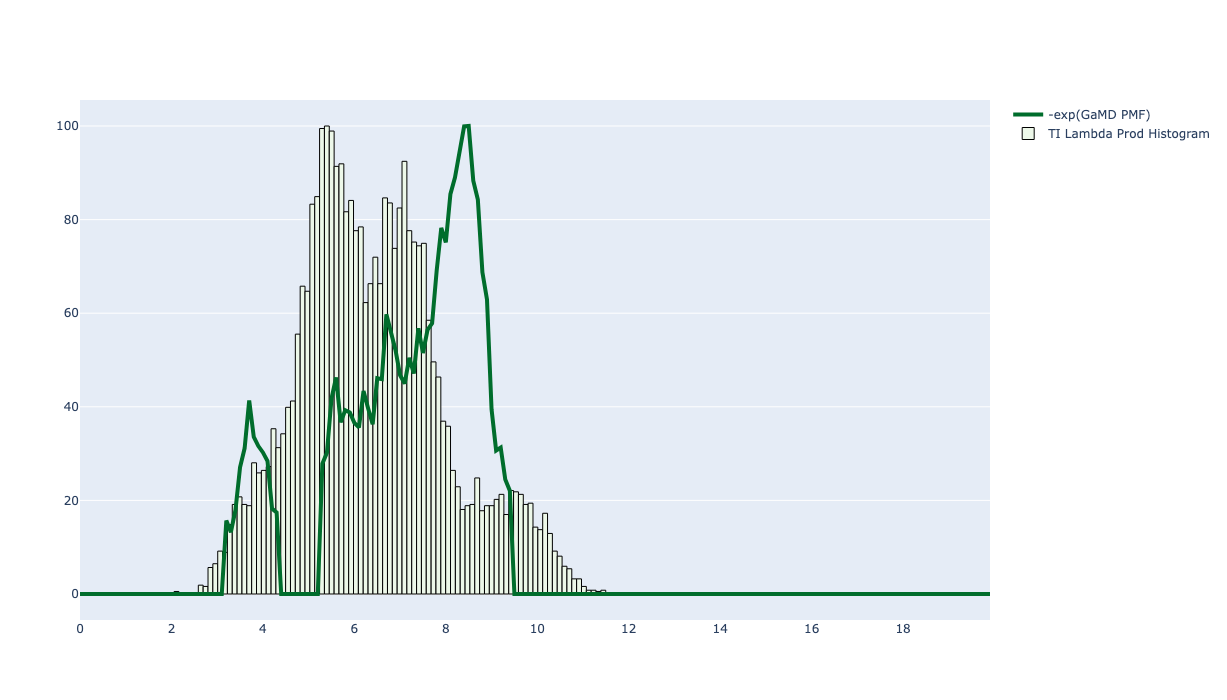

In [7]:
os.chdir("../../gamd_pmfs/VL-T31A")
r66_t31 = get_pmf("pmf-c2-R66_T31_bound.dat.xvg")
fig = plot_pmf_TI_1D_fig(r66_t31, geom_dvdls, "R421_T386", scaler=100, bins=100)
fig.update_layout(
    width=1000, height=700
).show(
    renderer="jupyterlab"
)

a1 = r66_t31[(r66_t31["X"] > 3.1) & (r66_t31["X"] < 4.4)]["pop"].sum()
a2 = r66_t31[(r66_t31["X"] > 5.2) & (r66_t31["X"] < 9.5)]["pop"].sum()

a1_prop = a1/(a1 + a2)
a2_prop = a2/(a1 + a2)

#### Computing dG of both microstates for bound state

In [8]:
st1 = geom_dvdls[(geom_dvdls["R421_T386"] > 3.1) & (geom_dvdls["R421_T386"] < 4.4)]
print(st1.groupby("Lambda").count()["weight_dvdl"])

st2 = geom_dvdls[(geom_dvdls["R421_T386"] > 5.2) & (geom_dvdls["R421_T386"] < 9.5)]
print(st2.groupby("Lambda").count()["weight_dvdl"])



Lambda
1       3
3     147
4      54
5      37
6     236
7      11
8      75
9     110
10    119
11    125
12     71
Name: weight_dvdl, dtype: int64
Lambda
1     828
2     949
3     826
4     826
5     827
6     491
7     839
8     587
9     597
10    631
11    573
12    747
Name: weight_dvdl, dtype: int64


#### Ingesting more data to sample left hand side better

We ran an additional set of 5 replicates of TI to obtain more sampling in the lambda values for the lefthand microstate. Even still, we have to rely on state 2's sampling of lambda 1 because microstate 1 does not have a sufficient sample size for this lambda value. 

In [11]:
geom_dvdls_boost = pd.read_csv("../../TI_data/VL-T31A/T31A_bound_boost.csv")

st1_missing = geom_dvdls_boost[
    (geom_dvdls_boost["R421_T386"] > 3.1) & 
    (geom_dvdls_boost["R421_T386"] < 4.4) & 
    (geom_dvdls_boost["Lambda"].isin([1,2,4,5,7,8,12]))
]
st1_boost = pd.concat([st1, st1_missing])
print(st1_boost.groupby("Lambda").count()["weight_dvdl"])

st2_lam1 = st2[st2["Lambda"] == 1]
st1_boost_fill = pd.concat([st1_boost, st2_lam1])

print(st1_boost_fill.groupby("Lambda").count()["weight_dvdl"])

Lambda
1      59
2     146
3     147
4     759
5     914
6     236
7     692
8     330
9     110
10    119
11    125
12    375
Name: weight_dvdl, dtype: int64
Lambda
1     887
2     146
3     147
4     759
5     914
6     236
7     692
8     330
9     110
10    119
11    125
12    375
Name: weight_dvdl, dtype: int64


In [12]:
st1_dGs = np.array(bootstrap_df(st1_boost_fill, 1000, 200))
st2_dGs = np.array(bootstrap_df(st2, 1000, 200))

corr_dGs = a1_prop * st1_dGs + a2_prop * st2_dGs

### Repeating for unbound state

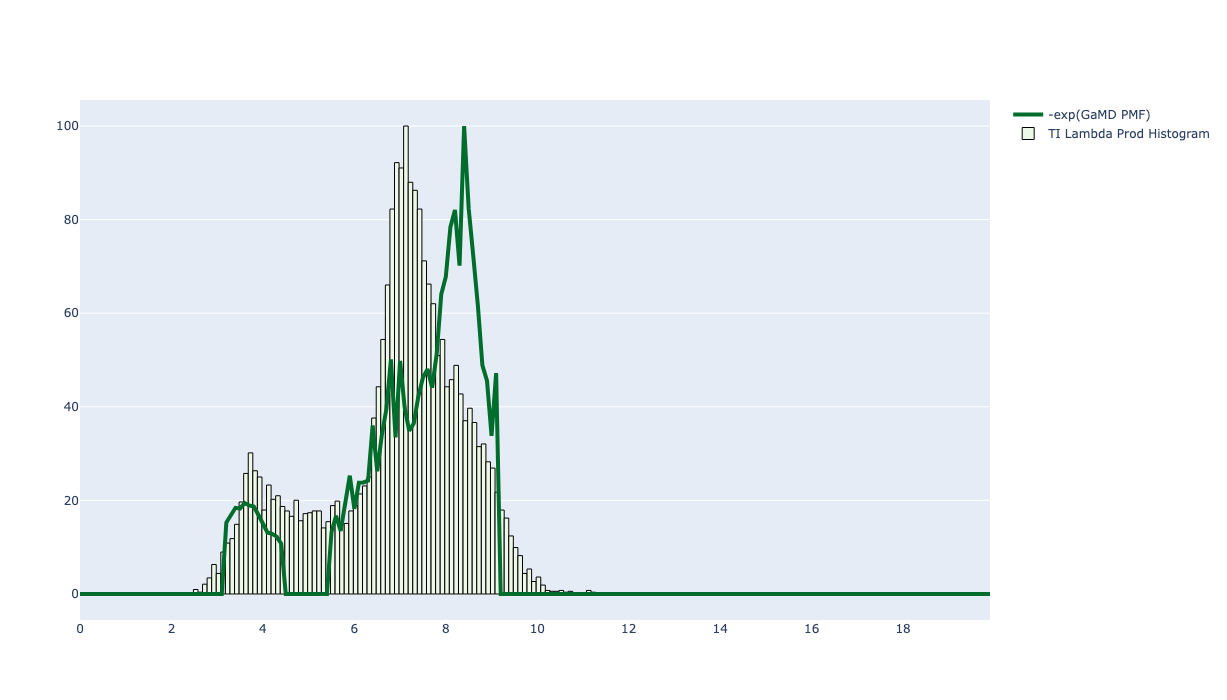

In [14]:
os.chdir("../../gamd_pmfs/VL-T31A")
r66_t31_ub = get_pmf("pmf-c2-R66_T31_unbound.dat.xvg")
fig = plot_pmf_TI_1D_fig(r66_t31_ub, geom_dvdls_ub, "T31_R66", scaler=100, bins=100)
fig.update_layout(
    width=1000, height=700
).show(
    renderer="jupyterlab"
)

a1ub = r66_t31[(r66_t31["X"] > 3.1) & (r66_t31["X"] < 4.5)]["pop"].sum()
a2ub = r66_t31[(r66_t31["X"] > 5.4) & (r66_t31["X"] < 9.2)]["pop"].sum()

a1_prop_ub = a1ub/(a1ub + a2ub)
a2_prop_ub = a2ub/(a1ub + a2ub)

#### Computing dG of both microstates, unbound state

The unbound state free energy profile looks quite similar to the bound state. Again, from seeing the comparison we get the sense that there is some hidden DOF that is not allowing the TI system to sample near its most favorable position from 7.7 - 9 Angstroms.

In [15]:
st1ub = geom_dvdls_ub[(geom_dvdls_ub["T31_R66"] > 3.1) & (geom_dvdls_ub["T31_R66"] < 4.5)]
print(st1ub.groupby("Lambda").count()["weight_dvdl"])

st2ub = geom_dvdls_ub[(geom_dvdls_ub["T31_R66"] > 5.4) & (geom_dvdls_ub["T31_R66"] < 9.2)]
print(st2ub.groupby("Lambda").count()["weight_dvdl"])

Lambda
1      67
2     121
3     158
4     226
5     132
6      79
7     157
8     184
9      95
10     81
11     42
12     77
Name: weight_dvdl, dtype: int64
Lambda
1     895
2     799
3     770
4     671
5     758
6     831
7     774
8     642
9     771
10    691
11    788
12    803
Name: weight_dvdl, dtype: int64


#### Ingesting extra sampling in unbound state 

In [16]:
geom_dvdls_boost_ub = pd.read_csv("../../TI_data/VL-T31A/T31A_unbound_boost.csv")

st1ub_missing = geom_dvdls_boost_ub[
    (geom_dvdls_boost_ub["T31_R66"] > 3.1) & 
    (geom_dvdls_boost_ub["T31_R66"] < 4.5) & 
    (geom_dvdls_boost_ub["Lambda"].isin([1,6,9,10,11,12]))
]

st1ub_boost = pd.concat([st1ub, st1ub_missing])
print(st1ub_boost.groupby("Lambda").count()["weight_dvdl"])

Lambda
1     108
2     121
3     158
4     226
5     132
6     173
7     157
8     184
9     424
10    220
11    401
12    249
Name: weight_dvdl, dtype: int64


In [18]:
st1ub_dGs = np.array(bootstrap_df(st1ub_boost, 1000, 200))
st2ub_dGs = np.array(bootstrap_df(st2ub, 1000, 200))
corr_dGs_ub = a1_prop_ub * st1ub_dGs + a2_prop_ub * st2ub_dGs

### Corrections summary

As we can see, there is a modest improvement after the correction. However, more work should be done to understand how and why the R66...T31 distance is so important and if it is just a proxy for a more geometric degree of freedom that is more strongly connected to energetics and TI DV/DL.

In [19]:
print("Corrected estimates: ")

corr_ddGs = print_summary(corr_dGs, corr_dGs_ub)
corr_err = abs(np.mean(corr_ddGs) - empirical_value)
print()
print(f"Corrected ddG error: {round(corr_err, 4)} kcal/mol")

Corrected estimates: 
Total ddG: 0.2394 +/- 0.3586
Lower CI: -0.1192
Upper CI: 0.5914

Corrected ddG error: 0.5606 kcal/mol


#### Re-printing original for comparison

In [20]:
print("Original estimates: ")
orig_ddGs = print_summary(orig_dGs, orig_ub_dGs)

print()
empirical_value = 0.80
orig_error = abs(np.mean(orig_ddGs) - empirical_value)
print(f"Original ddG error: {round(orig_error, 4)} kcal/mol")

Original estimates: 
Total ddG: -0.1523 +/- 0.4467
Lower CI: -0.5678
Upper CI: 0.2943

Original ddG error: 0.9523 kcal/mol
